# Assignment 3, Exercise 1

We study the AR(2) process

$$X_t + \phi_1 X_{t-1} + \phi_2 X_{t-2} = \epsilon_t,$$

where $\{\epsilon_t\}$ is white noise with standard deviation $\sigma_\epsilon = 1$.

In [ ]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import acf

N_REALIZATIONS = 5
N_OBSERVATIONS = 200
MAX_LAG = 30
SIGMA_EPSILON = 1.0
BASE_SEED = 1


OUTPUT_DIR = Path('exercise1_figures')
OUTPUT_DIR.mkdir(exist_ok=True)

plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.25

In [23]:
def simulate_ar2(phi1: float, phi2: float, n_obs: int, seed: int) -> np.ndarray:
    """Simulate X_t + phi1 X_{t-1} + phi2 X_{t-2} = epsilon_t."""
    rng = np.random.default_rng(seed)
    x = np.zeros(n_obs)
    eps = rng.normal(loc=0.0, scale=SIGMA_EPSILON, size=n_obs)

    for t in range(2, n_obs):
        x[t] = eps[t] - phi1 * x[t - 1] - phi2 * x[t - 2]

    return x


def empirical_acf(series: np.ndarray, max_lag: int) -> np.ndarray:
    return acf(series, nlags=max_lag, fft=False)


def characteristic_roots(phi1: float, phi2: float) -> np.ndarray:
    return np.roots([phi2, phi1, 1.0])


def is_stationary(phi1: float, phi2: float) -> bool:
    roots = characteristic_roots(phi1, phi2)
    return bool(np.all(np.abs(roots) > 1.0))


def theoretical_acf(phi1: float, phi2: float, max_lag: int):
    roots = characteristic_roots(phi1, phi2)
    if np.any(np.abs(roots) <= 1.0):
        return None

    rho = np.zeros(max_lag + 1)
    rho[0] = 1.0
    rho[1] = -phi1 / (1.0 + phi2)

    for k in range(2, max_lag + 1):
        rho[k] = -phi1 * rho[k - 1] - phi2 * rho[k - 2]

    return rho


def format_roots(phi1: float, phi2: float) -> str:
    roots = characteristic_roots(phi1, phi2)
    pieces = []
    for root in roots:
        if abs(root.imag) < 1e-12:
            pieces.append(f'{root.real:.3f}')
        else:
            pieces.append(f'{root.real:.3f}{root.imag:+.3f}j')
    return ', '.join(pieces)


def run_case(exercise: str, phi1: float, phi2: float, comment: str, slug: str, seed_offset: int):
    simulations = np.array([
        simulate_ar2(phi1, phi2, N_OBSERVATIONS, BASE_SEED + seed_offset + i)
        for i in range(N_REALIZATIONS)
    ])
    acfs = np.array([empirical_acf(series, MAX_LAG) for series in simulations])
    rho = theoretical_acf(phi1, phi2, MAX_LAG)

    return {
        'exercise': exercise,
        'phi1': phi1,
        'phi2': phi2,
        'comment': comment,
        'slug': slug,
        'simulations': simulations,
        'acfs': acfs,
        'rho': rho,
        'stationary': is_stationary(phi1, phi2),
    }


def plot_theoretical_acf(ax, lags: np.ndarray, rho: np.ndarray, label: str):

    ax.vlines(lags, 0.0, rho, colors='blue', linewidth=1.2, alpha=0.9)
    ax.plot(lags, rho, color='blue', marker='o', markersize=4, linestyle='None', label=label)


def plot_case(case, axes):
    time = np.arange(1, N_OBSERVATIONS + 1)
    lags = np.arange(MAX_LAG + 1)

    for idx, series in enumerate(case['simulations'], start=1):
        axes[0].plot(time, series, linewidth=1.0, alpha=0.85, label=f'Realization {idx}')
    axes[0].set_title(
        f"{case['exercise']}: 5 simulations of AR(2) with phi1={case['phi1']}, phi2={case['phi2']}"
    )
    axes[0].set_xlabel('t')
    axes[0].set_ylabel('X_t')
    axes[0].legend(ncol=3, fontsize=8)

    for idx, values in enumerate(case['acfs'], start=1):
        axes[1].plot(lags, values, linestyle = "--", linewidth=1.0, alpha=0.7, label=f'Empirical ACF {idx}')
    if case['rho'] is not None:
        plot_theoretical_acf(axes[1], lags, case['rho'], label='Theoretical rho(k)')
    axes[1].axhline(0.0, color='black', linewidth=0.8)
    axes[1].set_title(f"{case['exercise']}: empirical ACFs up to lag {MAX_LAG}")
    axes[1].set_xlabel('Lag k')
    axes[1].set_ylabel('ACF')
    axes[1].legend(ncol=2, fontsize=8)


def run_all_cases(cases, output_slug: str):
    prepared_cases = [run_case(**case) for case in cases]
    fig, axes = plt.subplots(
        len(prepared_cases),
        2,
        figsize=(16, 4.5 * len(prepared_cases)),
        constrained_layout=True,
        squeeze=False,
    )

    for row_axes, case in zip(axes, prepared_cases):
        plot_case(case, row_axes)

    figure_path = OUTPUT_DIR / f'{output_slug}.png'
    fig.savefig(figure_path, dpi=200)
    plt.show()
    plt.close(fig)

    for case in prepared_cases:
        print(f"{case['exercise']} | Roots: {format_roots(case['phi1'], case['phi2'])}")
        stationary_text = 'yes' if case['stationary'] else 'no'
        print(f'Stationary: {stationary_text}')
        print(case['comment'])
        print()

    print(f'Combined figure saved to: {figure_path}')
    return prepared_cases

## 1.1 and 1.2
Simulate 5 realizations for $\phi_1=-0.6$ and $\phi_2=0.5$, then compare the empirical ACFs with the theoretical $\rho(k)$.

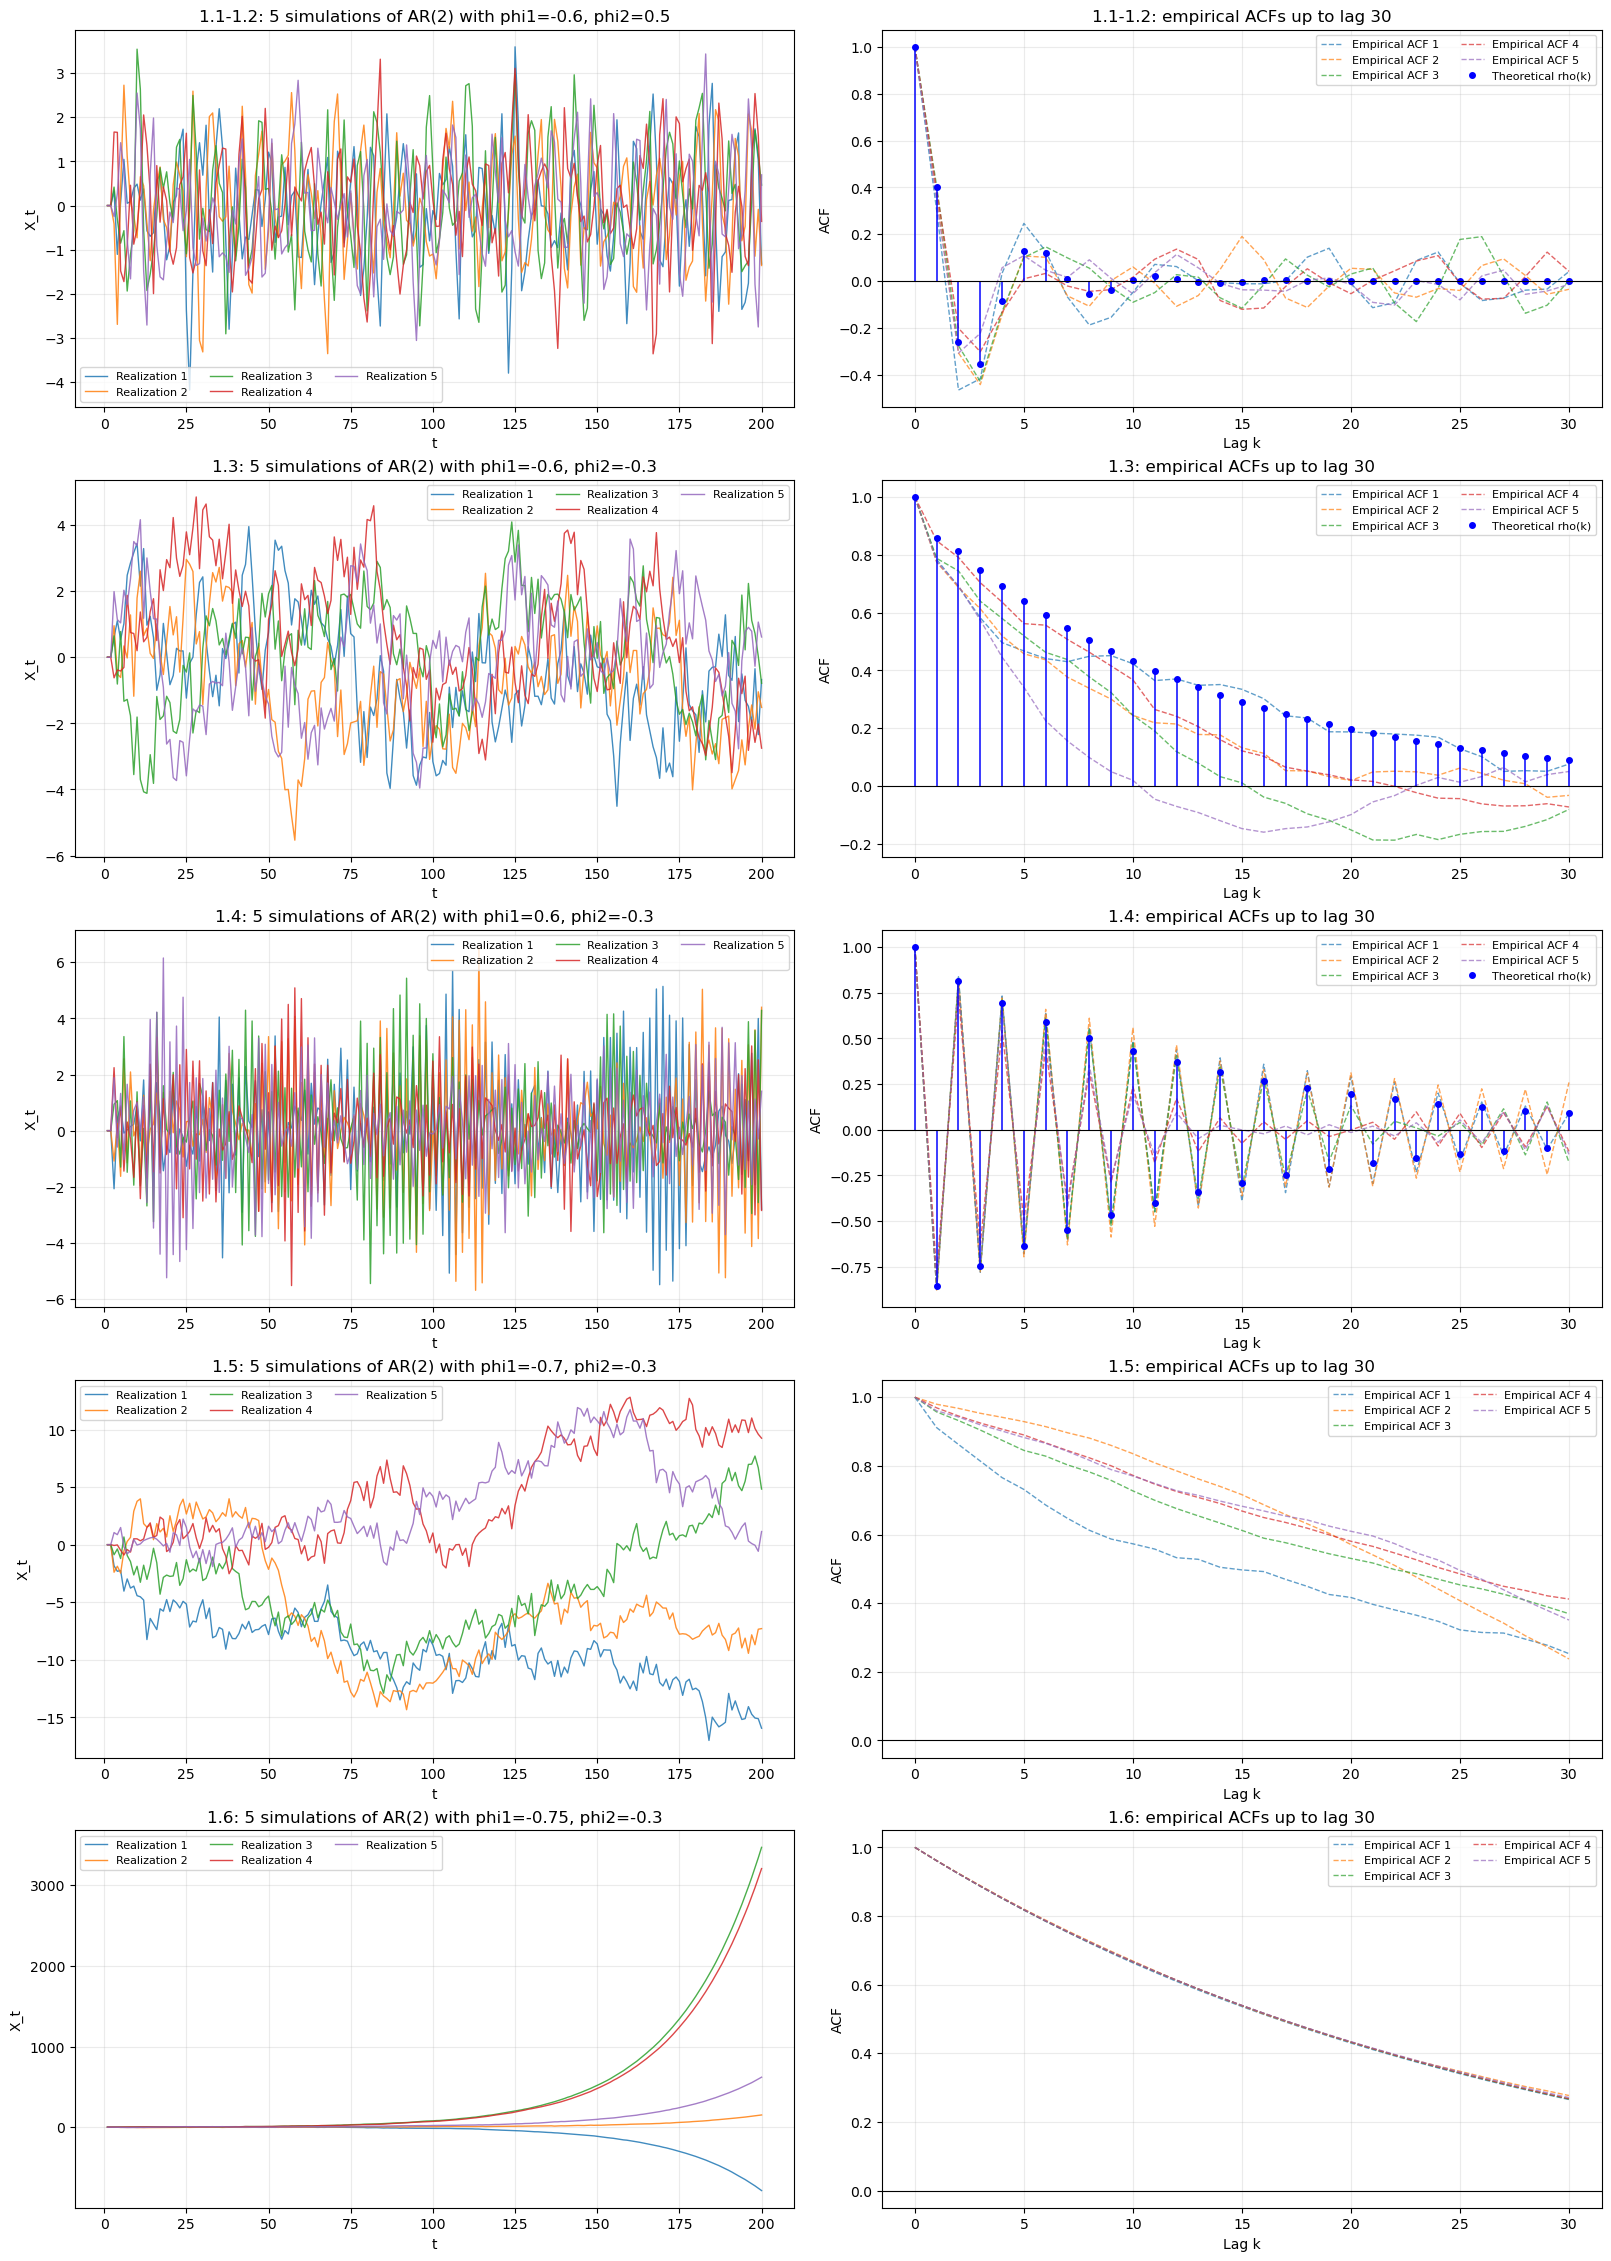

1.1-1.2 | Roots: 0.600+1.281j, 0.600-1.281j
Stationary: yes
Stationary. The realizations fluctuate around a constant level, and the empirical ACFs follow the theoretical damped oscillation reasonably well. Differences across the five ACFs are sampling noise from using only 200 observations.

1.3 | Roots: -3.082, 1.082
Stationary: yes
Stationary and strongly persistent. The series move more smoothly than in 1.1-1.2, and the ACF stays positive for many lags instead of alternating.

1.4 | Roots: 3.082, -1.082
Stationary: yes
Stationary. The negative first-order dependence creates more visible zig-zag behaviour, and the ACF alternates in sign while decaying toward zero.

1.5 | Roots: -3.333, 1.000
Stationary: no
On the stationarity boundary. One root is exactly on the unit circle, so the process is not stationary; realizations can drift for long stretches, and the ACF decays very slowly.

1.6 | Roots: -3.463, 0.963
Stationary: no
Non-stationary and unstable. At least one root lies inside t

[{'exercise': '1.1-1.2',
  'phi1': -0.6,
  'phi2': 0.5,
  'comment': 'Stationary. The realizations fluctuate around a constant level, and the empirical ACFs follow the theoretical damped oscillation reasonably well. Differences across the five ACFs are sampling noise from using only 200 observations.',
  'slug': 'case_12_phi1_-0.6_phi2_0.5',
  'simulations': array([[ 0.        ,  0.        ,  0.33043708, -1.10489499,  0.07720034,
           1.04514227,  0.05153196,  0.08946614,  0.3924861 ,  0.48489109,
           0.12311384,  0.37813575, -0.57112956, -0.69465556, -0.61334787,
           0.57816527,  0.6932952 , -0.16556226, -1.22789342, -0.91114716,
           0.07540059,  0.22521103,  1.39149014,  1.72901288, -2.36949982,
          -4.17521958, -1.49515393,  0.76832702,  1.42221617,  0.68648813,
           1.81862354, -0.3640907 , -1.5053712 ,  1.32159424,  2.19234514,
           1.31767334, -0.81957494, -2.7986568 , -1.10194187,  0.84717737,
          -0.1680747 , -1.20766017, -0.71

In [26]:
cases = [
    {
        'exercise': '1.1-1.2',
        'phi1': -0.6,
        'phi2': 0.5,
        'comment': (
            'Stationary. The realizations fluctuate around a constant level, and the empirical ACFs '
            'follow the theoretical damped oscillation reasonably well. Differences across the five ACFs '
            'are sampling noise from using only 200 observations.'
        ),
        'slug': 'case_12_phi1_-0.6_phi2_0.5',
        'seed_offset': 0,
    },
    {
        'exercise': '1.3',
        'phi1': -0.6,
        'phi2': -0.3,
        'comment': (
            'Stationary and strongly persistent. The series move more smoothly than in 1.1-1.2, '
            'and the ACF stays positive for many lags instead of alternating.'
        ),
        'slug': 'case_13_phi1_-0.6_phi2_-0.3',
        'seed_offset': 100,
    },
    {
        'exercise': '1.4',
        'phi1': 0.6,
        'phi2': -0.3,
        'comment': (
            'Stationary. The negative first-order dependence creates more visible zig-zag behaviour, '
            'and the ACF alternates in sign while decaying toward zero.'
        ),
        'slug': 'case_14_phi1_0.6_phi2_-0.3',
        'seed_offset': 200,
    },
    {
        'exercise': '1.5',
        'phi1': -0.7,
        'phi2': -0.3,
        'comment': (
            'On the stationarity boundary. One root is exactly on the unit circle, so the process is '
            'not stationary; realizations can drift for long stretches, and the ACF decays very slowly.'
        ),
        'slug': 'case_15_phi1_-0.7_phi2_-0.3',
        'seed_offset': 300,
    },
    {
        'exercise': '1.6',
        'phi1': -0.75,
        'phi2': -0.3,
        'comment': (
            'Non-stationary and unstable. At least one root lies inside the unit circle, so realizations '
            'show explosive behaviour and the empirical ACF is not interpretable as a stationary ACF.'
        ),
        'slug': 'case_16_phi1_-0.75_phi2_-0.3',
        'seed_offset': 400,
    },
]

run_all_cases(cases, output_slug='exercise1_combined')

## 1.3
Redo the simulations and ACFs with $\phi_1=-0.6$ and $\phi_2=-0.3$.

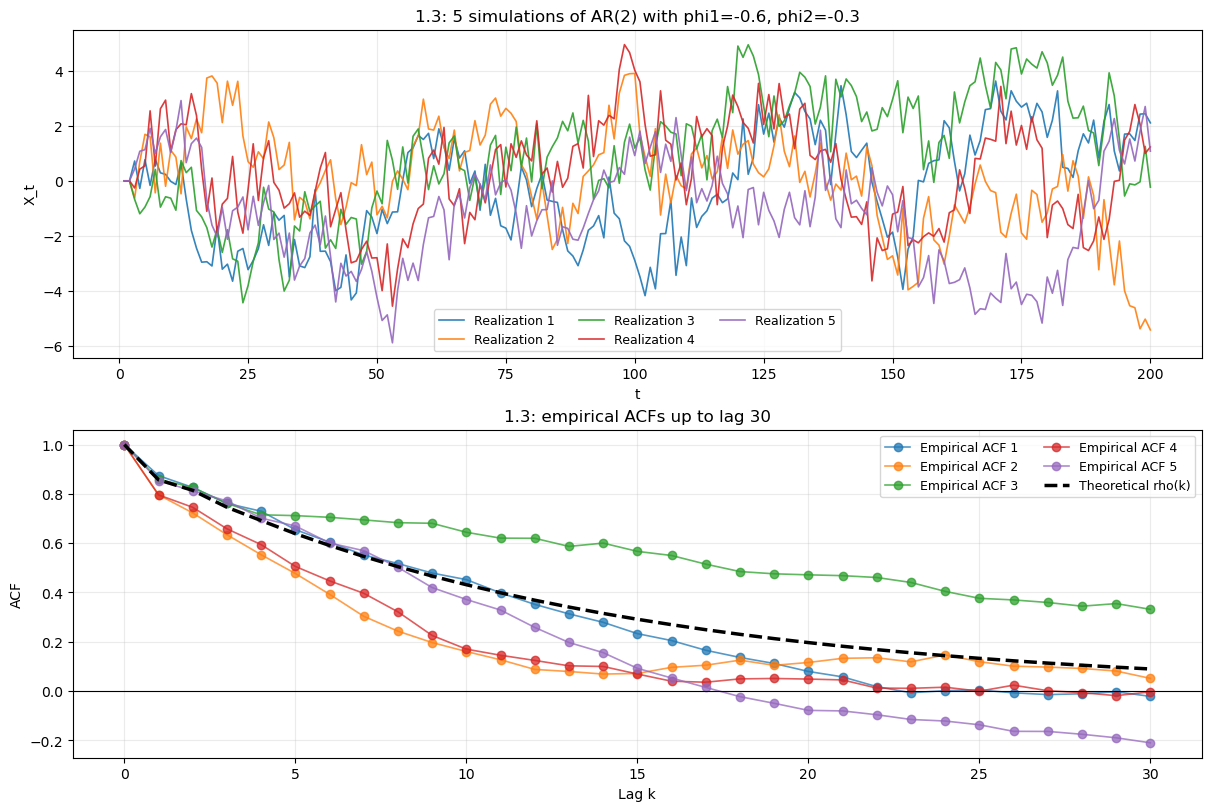

Roots: -3.082, 1.082
Stationary: yes
Stationary and strongly persistent. The series move more smoothly than in 1.1-1.2, and the ACF stays positive for many lags instead of alternating.
Figure saved to: exercise1_figures\case_13_phi1_-0.6_phi2_-0.3.png


In [5]:
# Included in the combined figure generated above.

## 1.4
Redo the simulations and ACFs with $\phi_1=0.6$ and $\phi_2=-0.3$.

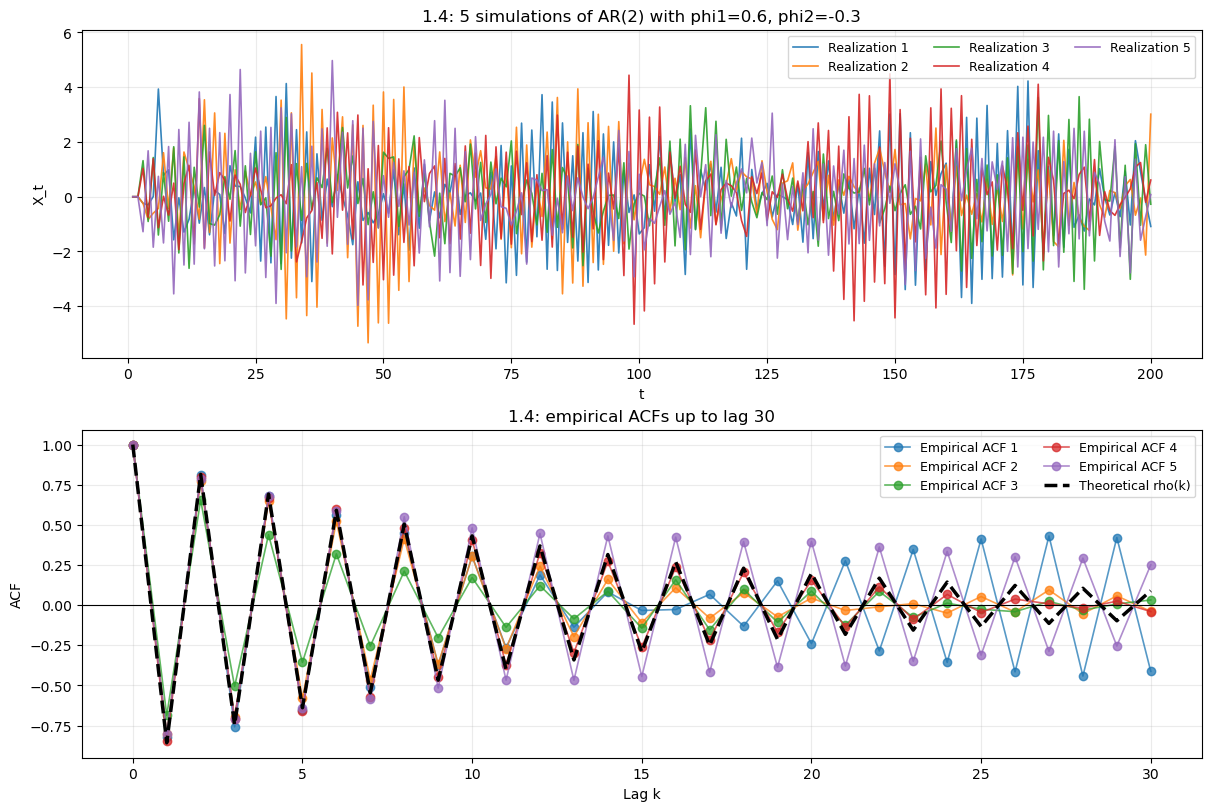

Roots: 3.082, -1.082
Stationary: yes
Stationary. The negative first-order dependence creates more visible zig-zag behaviour, and the ACF alternates in sign while decaying toward zero.
Figure saved to: exercise1_figures\case_14_phi1_0.6_phi2_-0.3.png


In [6]:
# Included in the combined figure generated above.

## 1.5
Redo the simulations and ACFs with $\phi_1=-0.7$ and $\phi_2=-0.3$.

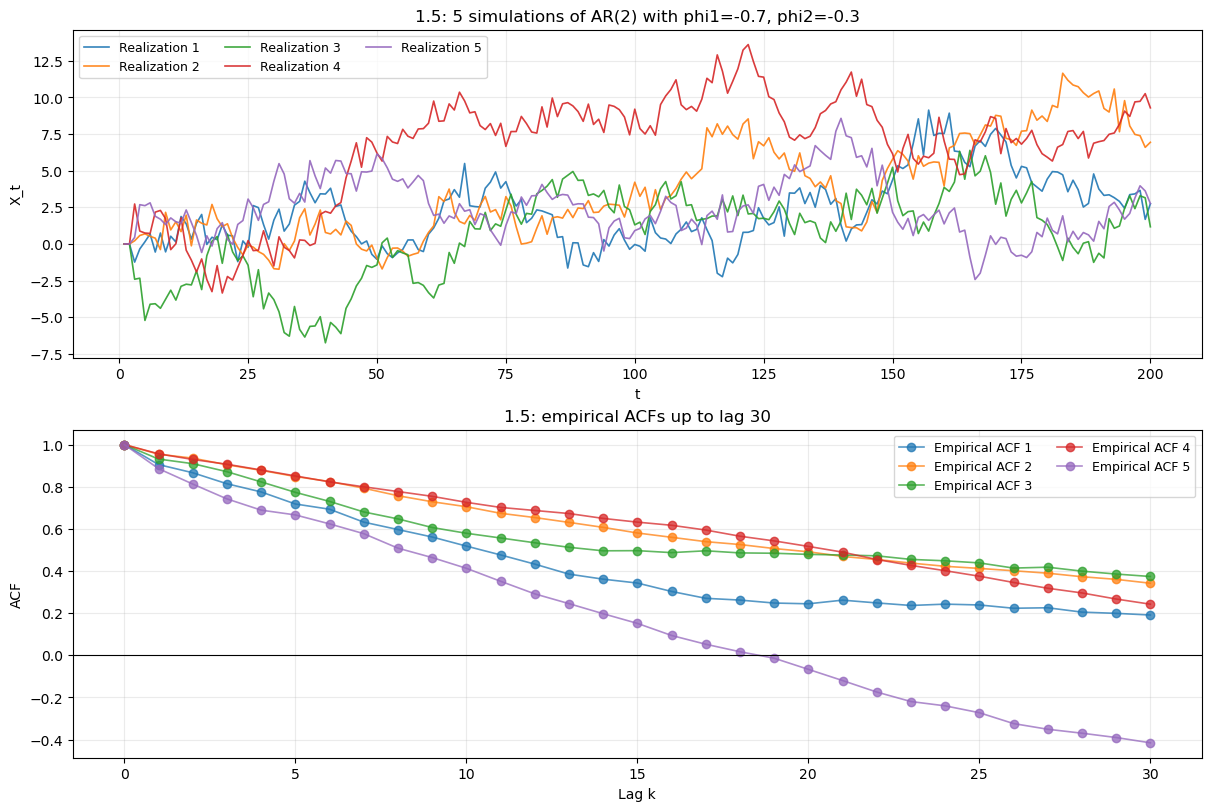

Roots: -3.333, 1.000
Stationary: no
On the stationarity boundary. One root is exactly on the unit circle, so the process is not stationary; realizations can drift for long stretches, and the ACF decays very slowly.
Figure saved to: exercise1_figures\case_15_phi1_-0.7_phi2_-0.3.png


In [8]:
# Included in the combined figure generated above.

## 1.6
Redo the simulations and ACFs with $\phi_1=-0.75$ and $\phi_2=-0.3$.

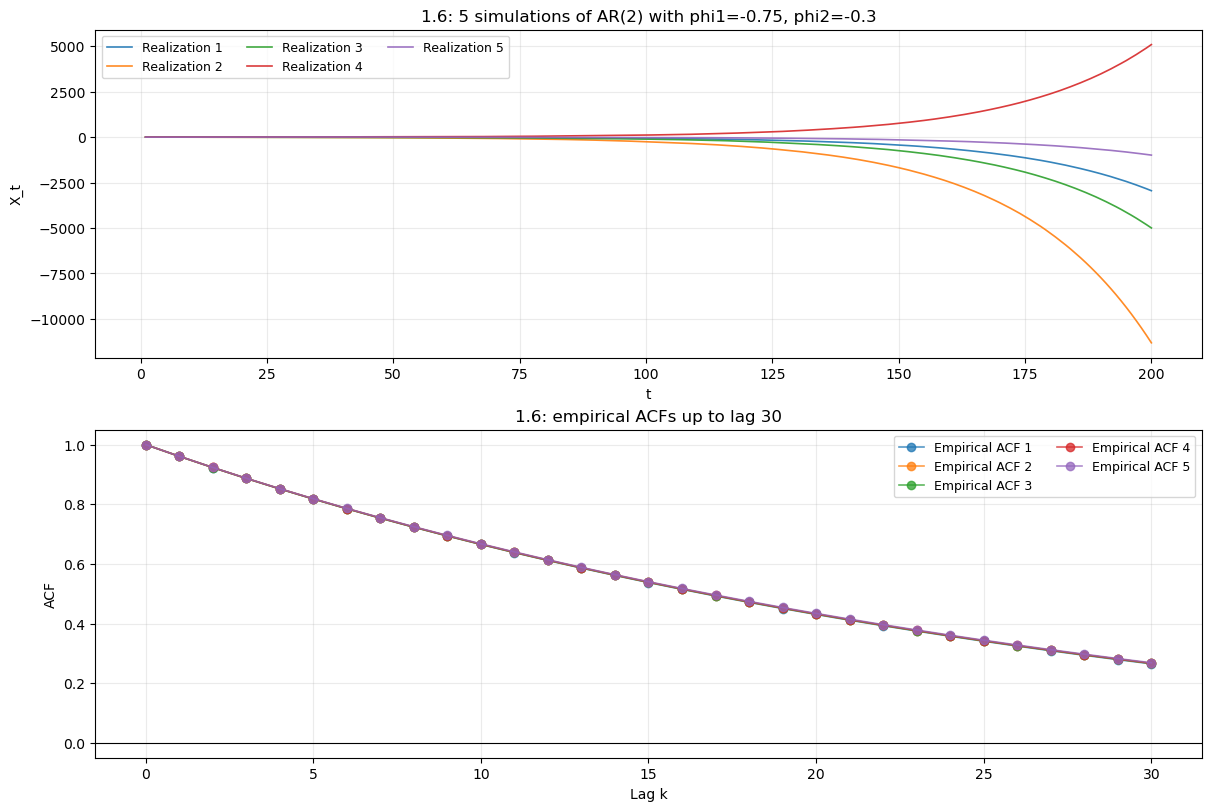

Roots: -3.463, 0.963
Stationary: no
Non-stationary and unstable. At least one root lies inside the unit circle, so realizations show explosive behaviour and the empirical ACF is not interpretable as a stationary ACF.
Figure saved to: exercise1_figures\case_16_phi1_-0.75_phi2_-0.3.png


In [9]:
# Included in the combined figure generated above.

## 1.7
I would not recommend relying only on the ACF. The ACF is useful for identifying serial dependence, but the time-series plot is still needed because it reveals non-stationarity, explosive behaviour, outliers, and visible path differences that the ACF alone can hide.

# Assignment 3, Exercise 2

This section solves Exercise 2 using `data_files/datasolar.csv` and the given model

$$
(1 + \phi_1 B)(1 + \phi_s B^{12})(\log(Y_t)-\mu)=\varepsilon_t,
$$

with $\phi_1=-0.38$, $\phi_s=-0.94$, $\mu=5.72$ and $\sigma_\varepsilon^2=0.22$.

In [ ]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from IPython.display import display
from statsmodels.graphics.gofplots import qqplot
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.stattools import acf

PHI_1 = -0.38
PHI_S = -0.94
MU = 5.72
SIGMA2 = 0.22**2
SEASONAL_LAG = 12

DATA_PATH = Path("data_files/datasolar.csv")


def load_solar_data() -> pd.DataFrame:
    df = pd.read_csv(DATA_PATH)
    df["date"] = pd.to_datetime(dict(year=df["year"], month=df["month"], day=1))
    df["X"] = np.log(df["power"]) - MU
    return df


def compute_residuals(x: np.ndarray) -> np.ndarray:
    residuals = []
    for t in range(SEASONAL_LAG + 1, len(x)):
        residual = x[t] + PHI_1 * x[t - 1] + PHI_S * x[t - SEASONAL_LAG] + PHI_1 * PHI_S * x[t - SEASONAL_LAG - 1]
        residuals.append(residual)
    return np.array(residuals)


def forecast_x(x: np.ndarray, steps: int = 12) -> np.ndarray:
    values = list(x)
    forecasts = []
    for _ in range(steps):
        t = len(values)
        next_x = -PHI_1 * values[t - 1] - PHI_S * values[t - SEASONAL_LAG] - PHI_1 * PHI_S * values[t - SEASONAL_LAG - 1]
        values.append(next_x)
        forecasts.append(next_x)
    return np.array(forecasts)


def forecast_std(steps: int = 12) -> np.ndarray:
    # The assignment note says to use the AR(1) part for the interval calculation.
    psi = np.array([(-PHI_1) ** j for j in range(steps)])
    return np.sqrt(SIGMA2 * np.cumsum(psi ** 2))


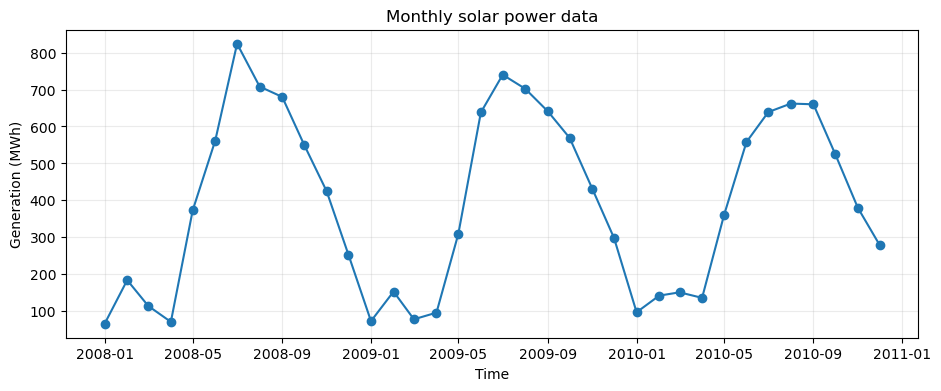

,year,month,power,date,X
0,2008,1,66,2008-01-01,-1.530345
1,2008,2,184,2008-02-01,-0.505064
2,2008,3,114,2008-03-01,-0.983802
3,2008,4,71,2008-04-01,-1.457320
4,2008,5,373,2008-05-01,0.201578


In [3]:
solar = load_solar_data()

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(solar["date"], solar["power"], marker="o", linewidth=1.5)
ax.set_title("Monthly solar power data")
ax.set_xlabel("Time")
ax.set_ylabel("Generation (MWh)")
ax.grid(alpha=0.25)
plt.show()

solar.head()

## 2.1 Residuals and model validation

Let

$$
X_t = \log(Y_t) - \mu.
$$

Then the model becomes

$$
X_t + \phi_1 X_{t-1} + \phi_s X_{t-12} + \phi_1\phi_s X_{t-13} = \varepsilon_t.
$$

With the given parameter values,

$$
\hat\varepsilon_t = X_t - 0.38X_{t-1} - 0.94X_{t-12} + 0.3572X_{t-13}, \qquad t=14,\ldots,36.
$$

These are the one-step-ahead residuals $\hat\varepsilon_{t|t-1}$ used for model validation.

In [ ]:
x = solar["X"].to_numpy()
residuals = compute_residuals(x)
residual_dates = solar["date"].iloc[SEASONAL_LAG + 1 :]

residual_summary = pd.Series(
    {
        "residual_mean": residuals.mean(),
        "residual_std": residuals.std(ddof=1),
        "acf_lag_1": acf(residuals, nlags=6, fft=False)[1],
        "ljung_box_pvalue_lag6": acorr_ljungbox(residuals, lags=[6], return_df=True)["lb_pvalue"].iloc[0],
        "shapiro_pvalue": stats.shapiro(residuals).pvalue,
        "rough_95_acf_band": 2 / np.sqrt(len(residuals)),
    }
)

display(residual_summary.to_frame("value"))

fig, axes = plt.subplots(2, 2, figsize=(12, 8), constrained_layout=True)

axes[0, 0].plot(residual_dates, residuals, marker="o", linewidth=1.2)
axes[0, 0].axhline(0.0, color="black", linewidth=0.8)
axes[0, 0].set_title("Residuals over time")
axes[0, 0].set_ylabel("Residual")
axes[0, 0].tick_params(axis="x", rotation=30)

axes[0, 1].hist(residuals, bins=8, edgecolor="black", alpha=0.8)
axes[0, 1].set_title("Residual histogram")

residual_acf = acf(residuals, nlags=min(10, len(residuals) - 1), fft=False)
axes[1, 0].stem(np.arange(len(residual_acf)), residual_acf)
axes[1, 0].axhline(0.0, color="black", linewidth=0.8)
axes[1, 0].axhline(2 / np.sqrt(len(residuals)), color="red", linestyle="--", linewidth=1.0)
axes[1, 0].axhline(-2 / np.sqrt(len(residuals)), color="red", linestyle="--", linewidth=1.0)
axes[1, 0].set_title("Residual ACF")
axes[1, 0].set_xlabel("Lag")

qqplot(residuals, line="s", ax=axes[1, 1])
axes[1, 1].set_title("Residual QQ plot")

#plt.show()

NameError: name 'solar' is not defined

The residual diagnostics are acceptable for such a short sample.

- The residual mean is approximately `0.013`, so the errors are centered close to zero.
- The lag-1 residual autocorrelation is about `-0.35`, which is still inside the rough 95% band `±0.42`.
- The Ljung-Box p-value at lag 6 is about `0.567`, so there is no strong evidence of remaining autocorrelation.
- The QQ plot and Shapiro-Wilk p-value (`0.152`) do not show a severe normality problem, although the right tail is a bit heavy.

Conclusion: the i.i.d. error assumption looks reasonable, but the validation is based on only 23 residuals, so it should not be overstated.

## 2.2 Twelve-month forecasts

For $t=36$ and $h=1,\ldots,12$, the forecast recursion on the log scale is

$$
\hat X_{36+h\mid 36}
= -\phi_1 \hat X_{35+h\mid 36}
- \phi_s X_{24+h}
- \phi_1\phi_s X_{23+h},
$$

where the seasonal lag terms are still observed values because $h \le 12$.

The original power forecasts are obtained by

$$
\hat Y_{36+h\mid 36} = \exp(\hat X_{36+h\mid 36} + \mu).
$$

In [5]:
forecast_dates = pd.date_range(solar["date"].iloc[-1] + pd.offsets.MonthBegin(), periods=12, freq="MS")
forecast_x_values = forecast_x(x, steps=12)
forecast_power = np.exp(forecast_x_values + MU)

forecast_table = pd.DataFrame(
    {
        "month": forecast_dates.strftime("%Y-%m"),
        "forecast_X": forecast_x_values,
        "forecast_power_MWh": forecast_power,
    }
)

display(forecast_table.round(3))

,month,forecast_X,forecast_power_MWh
0,2011-01,-1.102,101.278
1,2011-02,-0.728,147.226
2,2011-03,-0.664,156.923
3,2011-04,-0.760,142.550
4,2011-05,0.153,355.310
5,2011-06,0.568,538.020
6,2011-07,0.695,611.205
7,2011-08,0.729,631.893
8,2011-09,0.726,630.110
9,2011-10,0.511,508.157


The forecasts preserve the strong seasonal pattern in the data: low production in winter, a sharp ramp-up in spring, and a peak around July to September.

## 2.3 Prediction intervals

Using the assignment shortcut, the prediction interval calculation uses only the AR(1) part. For $h \le 12$,

$$
\psi_j = (-\phi_1)^j = 0.38^j,
$$

so

$$
\mathrm{Var}(X_{36+h} - \hat X_{36+h\mid 36})
= \sigma_\varepsilon^2 \sum_{j=0}^{h-1} \psi_j^2.
$$

The 95% interval on the log scale is

$$
\hat X_{36+h\mid 36} \pm 1.96\,s_h,
$$

and the interval is transformed back to the power scale by exponentiating the two endpoints.

,month,forecast_X,forecast_power_MWh,std_error_log,lower_95_MWh,upper_95_MWh
0,2011-01,-1.102,101.278,0.220,65.804,155.876
1,2011-02,-0.728,147.226,0.235,92.823,233.514
2,2011-03,-0.664,156.923,0.237,98.523,249.937
3,2011-04,-0.760,142.550,0.238,89.446,227.182
4,2011-05,0.153,355.310,0.238,222.927,566.307
5,2011-06,0.568,538.020,0.238,337.558,857.527
6,2011-07,0.695,611.205,0.238,383.475,974.177
7,2011-08,0.729,631.893,0.238,396.454,1007.151
8,2011-09,0.726,630.110,0.238,395.335,1004.309
9,2011-10,0.511,508.157,0.238,318.821,809.932


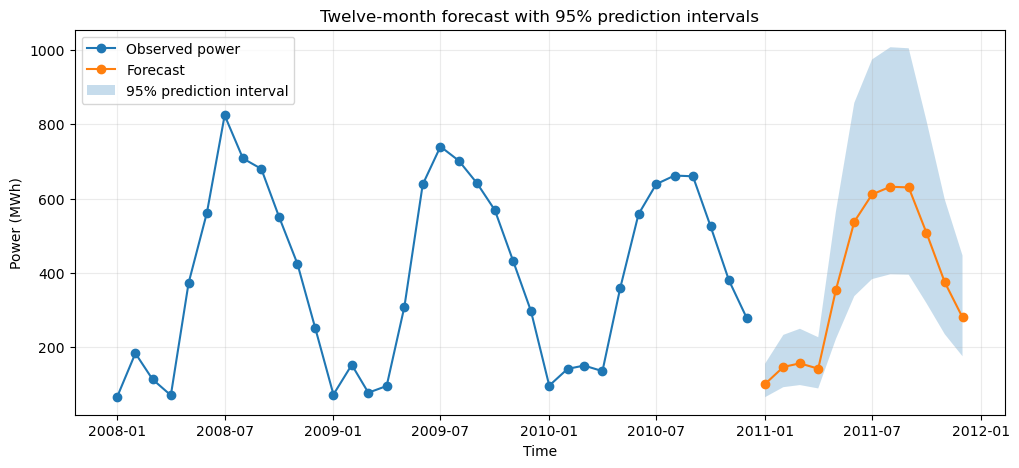

In [7]:
z_value = stats.norm.ppf(0.975)
forecast_std_values = forecast_std(steps=12)

forecast_table["std_error_log"] = forecast_std_values
forecast_table["lower_95_MWh"] = np.exp(forecast_x_values + MU - z_value * forecast_std_values)
forecast_table["upper_95_MWh"] = np.exp(forecast_x_values + MU + z_value * forecast_std_values)

display(forecast_table.round(3))

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(solar["date"], solar["power"], marker="o", linewidth=1.5, label="Observed power")
ax.plot(forecast_dates, forecast_table["forecast_power_MWh"], marker="o", linewidth=1.5, label="Forecast")
ax.fill_between(
    forecast_dates,
    forecast_table["lower_95_MWh"],
    forecast_table["upper_95_MWh"],
    alpha=0.25,
    label="95% prediction interval",
)
ax.set_title("Twelve-month forecast with 95% prediction intervals")
ax.set_xlabel("Time")
ax.set_ylabel("Power (MWh)")
ax.grid(alpha=0.25)
ax.legend()
plt.show()

## 2.4 Comment on the forecast

I would trust the forecast as a rough seasonal baseline, but not as a precise monthly prediction.

- The point forecasts look plausible because they follow the observed yearly pattern quite closely.
- The residual checks do not show a major model failure, but the sample is very small.
- The 95% intervals are much wider in the summer months on the original MWh scale. That does not mean the log-scale uncertainty suddenly explodes; it mainly comes from the exponential back-transformation.
- Because the intervals depend on the forecast level, their width is not equally informative all year. They are much more dramatic when the expected production is high.

So the model is useful for planning at a broad level, but it should not be over-trusted for exact monthly values or for interval widths on the original scale.